In [2]:
import json
with open("data/golgg_games.json") as f:
    games = json.load(f)


print(len(games))
games = list({g["game_id"]:g for g in games}.values())
print(len(games))
games = sorted(games, key=lambda x: (x["date"], x["match_id"], x["game_id"]))


62530
62456


In [3]:
matches = {}
for g in games:
    mid = g["match_id"]
    if mid not in matches:
        matches[mid] = {
            "match_id": mid,
            "date": g["date"],
            "tournament": g["tournament"],
            "name_1": g["t1_name"],
            "name_2": g["t2_name"],
            "tid_1": g["t1_id"],
            "tid_2": g["t2_id"],
            "score_1": 0,
            "score_2": 0,
            "players_1": [p["player_id"] for p in g["t1_players"].values()],
            "players_2": [p["player_id"] for p in g["t2_players"].values()],
            "games": []
        }
    
    t1_win = g["t1_win"]
    if g["t1_id"] != matches[mid]["tid_1"]:
        t1_win = 1 - t1_win  # swap if team ids don't match
    matches[mid]["score_1"] += int(t1_win)
    matches[mid]["score_2"] += int(1 - t1_win)
    matches[mid]["t1_win"] = matches[mid]["score_1"] > matches[mid]["score_2"]
    matches[mid]["t2_win"] = matches[mid]["score_2"] > matches[mid]["score_1"]
    matches[mid]["draw"] = matches[mid]["score_1"] == matches[mid]["score_2"]
    matches[mid]["BoN"] = max(matches[mid]["score_1"], matches[mid]["score_2"]) * 2 - 1 if not matches[mid]["draw"] else matches[mid]["score_1"]*2

    matches[mid]["games"].append(g)

matches = list(sorted(matches.values(), key=lambda x: (x["date"], x["match_id"])))

In [7]:
len(matches)
import json 

with open("golgg_matches.json", "w") as f:
    json.dump(matches, f)

In [1]:
import json 
with open("golgg_matches.json", 'r') as f:
    matches = json.load(f)

print(len(matches))
matches = [match for match in matches if not match["draw"]]
print(len(matches))

39810
39315


In [2]:
from src.ratings.manager import RatingManager

manager = RatingManager()

y_predicts = {
    "team_elo": [],
    "team_gl": [],
    "team_ts": [],
    "team_pl": [],
    "team_tm": [],
    "player_elo": [],
    "player_gl": [],
    "player_ts": [],
    "player_pl": [],
    "player_tm": [],
    "bon_team_elo": [],
    "bon_team_gl": [],
    "bon_team_ts": [],
    "bon_team_pl": [],
    "bon_team_tm": [],
    "bon_player_elo": [],
    "bon_player_gl": [],
    "bon_player_ts": [],
    "bon_player_pl": [],
    "bon_player_tm": [],
    "BoN": [],
    "date": []
}

In [3]:
from src.utils.helpers import match_win_probability

def add_bon_predictions(predictions, bon):
    for key in list(predictions.keys()):
        p = predictions[key]
        bon_p = match_win_probability(p, bon)
        predictions[f"bon_{key}"] = bon_p

def add_to_y_predicts(y_predicts, predictions, bon, date):
    for key, value in predictions.items():
        y_predicts[key].append(value)

    y_predicts["BoN"].append(bon)
    y_predicts["date"].append(date)
    predictions["BoN"] = bon
    predictions["date"] = date

In [5]:
from sklearn.metrics import roc_auc_score, accuracy_score
from tqdm import tqdm
from dateutil.relativedelta import relativedelta
from datetime import date
import pandas as pd

y_trues = []
interval_y_true = []
INTERVAL_YEARS = 2
interval_predictions = []
end_date = date.fromisoformat("2014-01-01")
aucs = []

for match in tqdm(matches, desc="Processing matches"):
    mid = match["match_id"]
    t1 = match["tid_1"]
    t2 = match["tid_2"]
    match_date = date.fromisoformat(match["date"])
    players_1 = match["players_1"]
    players_2 = match["players_2"]
    scores = []
    
    manager.update_before_match(t1, t2, players_1, players_2, match_date)
    predictions = manager.predict_match(t1, t2, players_1, players_2)
    add_bon_predictions(predictions, match["BoN"])

    interval_predictions.append({
        "date": match_date,
        **predictions
    })
    interval_y_true.append({"date": match_date, "y_true": int(match["t1_win"])})
    add_to_y_predicts(y_predicts, predictions, match["BoN"], match_date)
    y_trues.append(int(match["t1_win"]))

    if match_date >= end_date:
        end_date += relativedelta(months=2)
        df = pd.DataFrame(interval_predictions)
        X = df["player_gl"]
        y = pd.DataFrame(interval_y_true)["y_true"]
        auc = roc_auc_score(y, X)
        acc = accuracy_score(y, [1 if p >= 0.5 else 0 for p in X])
        aucs.append({
            "date": end_date, "auc": auc, "accuracy": acc, "n_matches": len(y)})
        back_date = end_date 
        interval_predictions = [pred for pred in interval_predictions if pred["date"] >= end_date - relativedelta(months=4)]
        interval_y_true = [yt for yt in interval_y_true if yt["date"] >= end_date - relativedelta(months=4)]
        if auc <= 0.7:
            print(f"Warning: AUC dropped below 0.7 ({auc}) for interval {end_date - relativedelta(months=4)} - {end_date}")

    for game in match["games"]:
        score_1 = int(game["t1_win"])
        score_2 = 1 - score_1
        if game["t1_id"] != match["tid_1"]:
            score_1, score_2 = score_2, score_1  # swap if team ids don't match

        scores.append(score_1)
        manager.update_after_game(t1, t2, players_1, players_2, score_1, score_2)

    manager.update_after_match(t1, t2, players_1, players_2, scores)

Processing matches:   0%|          | 0/39315 [00:00<?, ?it/s]


KeyError: 'team_elo_r1'

In [14]:
# with open("golgg_y_predicts.json", 'w') as f:
#     # Fix dates to isoformat
#     for i in range(len(y_predicts["date"])):
#         y_predicts["date"][i] = y_predicts["date"][i].isoformat()
#     json.dump(y_predicts, f, indent=2)

df = pd.DataFrame(y_predicts)
df["y_true"] = y_trues
df.to_csv("golgg_y_predicts.csv", index=False)

In [15]:
df = pd.read_csv("golgg_y_predicts.csv")
df["date"] = pd.to_datetime(df["date"]).dt.date

28243
AUC Scores:
Player Glicko: 0.739
Player Elo: 0.727
Player PlackettLuce: 0.723
Player TrueSkill: 0.715
Player ThurstoneMostellerFull: 0.700


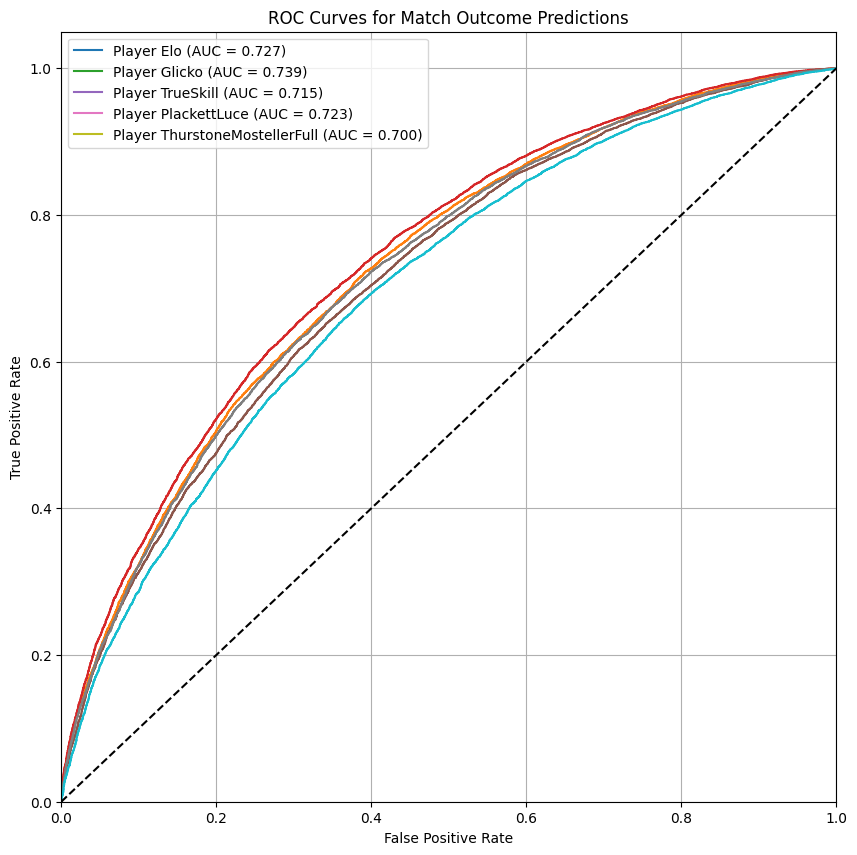

In [16]:
import pandas as pd
interval_df = df[(df["date"] >= date.fromisoformat("2020-01-01"))]
X = interval_df.drop(columns=["y_true"])
y = interval_df["y_true"]
print(len(y))

metrics = {
    # "Team Elo": "team_elo",
    # "Team Glicko": "team_gl",
    # "Team TrueSkill": "team_ts",
    # "Team PlackettLuce": "team_pl",
    # "Team ThurstoneMostellerFull": "team_tm",
    "Player Elo": "player_elo",
    "Player Glicko": "player_gl",
    "Player TrueSkill": "player_ts",
    "Player PlackettLuce": "player_pl",
    "Player ThurstoneMostellerFull": "player_tm",
#     "Bon Team Elo": "bon_team_elo",
#     "Bon Team Glicko": "bon_team_gl",
#     "Bon Team TrueSkill": "bon_team_ts",
#     "Bon Team PlackettLuce": "bon_team_pl",
#     "Bon Team ThurstoneMostellerFull": "bon_team_tm",
#     "Bon Player Elo": "bon_player_elo",
#     "Bon Player Glicko": "bon_player_gl",
#     "Bon Player TrueSkill": "bon_player_ts",
#     "Bon Player PlackettLuce": "bon_player_pl",
#     "Bon Player ThurstoneMostellerFull": "bon_player_tm"
}


# Plot ROC
from sklearn.metrics import roc_auc_score, roc_curve, roc_curve
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
aucs = {}
for name, col in metrics.items():
    auc = roc_auc_score(y, X[col])
    aucs[name] = auc
    plt.plot([], [], label=f"{name} (AUC = {auc:.3f})")
    fpr, tpr, _ = roc_curve(y, X[col])
    plt.plot(fpr, tpr)
    
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid()
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Match Outcome Predictions')
plt.legend()

aucs = dict(sorted(aucs.items(), key=lambda item: item[1], reverse=True))
print("AUC Scores:")
for name, auc in aucs.items():
    print(f"{name}: {auc:.3f}")


# plt.legend(loc="lower right")
# plt.show()

Player Elo Mean: 0.51, Std: 0.17
Team Elo Mean: 0.51, Std: 0.20


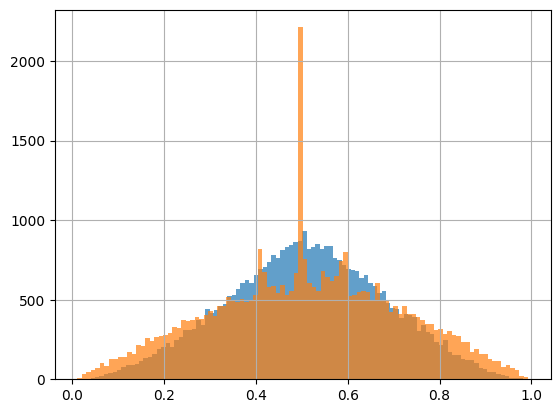

In [17]:
df["player_elo"].hist(bins=100, alpha=0.7)
mean, std = df["player_elo"].mean(), df["player_elo"].std()
print(f"Player Elo Mean: {mean:.2f}, Std: {std:.2f}")

df["team_elo"].hist(bins=100, alpha=0.7)
mean, std = df["team_elo"].mean(), df["team_elo"].std()
print(f"Team Elo Mean: {mean:.2f}, Std: {std:.2f}")



<Axes: >

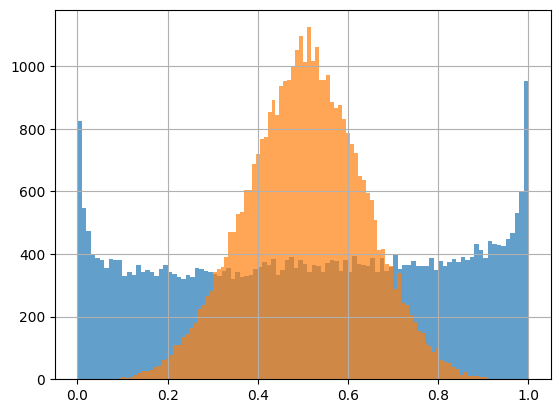

In [18]:
# df["player_elo"].hist(bins=100, alpha=0.7)
# df["player_gl"].hist(bins=100, alpha=0.7)
# df.head()
df["player_pl"].hist(bins=100, alpha=0.7)
df["player_ts"].hist(bins=100, alpha=0.7)
# plt.legend(["Elo", "Glicko", "PlackettLuce", "TrueSkill"])

In [19]:
from sklearn.metrics import brier_score_loss


metrics = {
    "Player Elo": "player_elo",
    "Player Glicko": "player_gl",
    "Player TrueSkill": "player_ts",
    "Player PlackettLuce": "player_pl",
}
idf = df[(df["date"] >= date.fromisoformat("2025-01-01"))]
print("Overall Metrics (from 2025-01-01):")
print(f"Number of matches: {len(idf)}")
for name, col in metrics.items():
    mean = df[col].mean()
    std = df[col].std()
    print(f"{name} - Mean: {mean:.4f}, Std: {std:.4f}")
    auc = roc_auc_score(idf["y_true"], idf[col])
    print(f"{name} - AUC: {auc:.4f}")
    logloss = - (idf["y_true"] * idf[col].apply(lambda p: math.log(p + 1e-15)) + (1 - idf["y_true"]) * idf[col].apply(lambda p: math.log(1 - p + 1e-15))).mean()
    print(f"{name} - Log Loss: {logloss:.4f}")
    brier = brier_score_loss(idf["y_true"], idf[col])
    print(f"{name} - Brier Score: {brier:.4f}")
    for bon in [1, 3, 5]:
        print(f"Metrics for Bon {bon}:")
        bon_idf = idf[idf["BoN"] == bon]
        print(f"  Number of matches: {len(bon_idf)}")
        bon_auc = roc_auc_score(bon_idf["y_true"], bon_idf[f"bon_{col}"])
        print(f"  Bon {bon} AUC: {bon_auc:.4f}")
        logloss = - (bon_idf["y_true"] * bon_idf[col].apply(lambda p: math.log(p + 1e-15)) + (1 - bon_idf["y_true"]) * bon_idf[col].apply(lambda p: math.log(1 - p + 1e-15))).mean()
        print(f"  Bon {bon} Log Loss: {logloss:.4f}")
        brier = brier_score_loss(bon_idf["y_true"], bon_idf[f"bon_{col}"])
        print(f"  Bon {bon} Brier Score: {brier:.4f}")


Overall Metrics (from 2025-01-01):
Number of matches: 3781
Player Elo - Mean: 0.5090, Std: 0.1705
Player Elo - AUC: 0.7439
Player Elo - Log Loss: 0.5954
Player Elo - Brier Score: 0.2049
Metrics for Bon 1:
  Number of matches: 1397
  Bon 1 AUC: 0.7200
  Bon 1 Log Loss: 0.6115
  Bon 1 Brier Score: 0.2120
Metrics for Bon 3:
  Number of matches: 1777
  Bon 3 AUC: 0.7659
  Bon 3 Log Loss: 0.5797
  Bon 3 Brier Score: 0.1967
Metrics for Bon 5:
  Number of matches: 607
  Bon 5 AUC: 0.7379
  Bon 5 Log Loss: 0.6043
  Bon 5 Brier Score: 0.2055
Player Glicko - Mean: 0.5096, Std: 0.1889
Player Glicko - AUC: 0.7614
Player Glicko - Log Loss: 0.5858
Player Glicko - Brier Score: 0.2004
Metrics for Bon 1:
  Number of matches: 1397
  Bon 1 AUC: 0.7395
  Bon 1 Log Loss: 0.5979
  Bon 1 Brier Score: 0.2060
Metrics for Bon 3:
  Number of matches: 1777
  Bon 3 AUC: 0.7847
  Bon 3 Log Loss: 0.5698
  Bon 3 Brier Score: 0.1890
Metrics for Bon 5:
  Number of matches: 607
  Bon 5 AUC: 0.7476
  Bon 5 Log Loss: 0.60

In [20]:
p1 = [pl_model.rating() for _ in range(5)]

In [21]:
p2 = [pl_model.rating(27, sigma=20) for _ in range(5)]

In [22]:
pl_model.predict_win([p1, p2])

[0.4194457519547652, 0.5805542480452348]

In [23]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, roc_auc_score, brier_score_loss
from sklearn.preprocessing import StandardScaler

# Zakładam, że Twój dataframe nazywa się 'df'
# 1. Sortowanie po dacie (Kluczowe!)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# 2. Wybór cech (X)
# Używamy wersji 'bon_*', bo one już zawierają info o formacie serii (Bo1/Bo3/Bo5)
# Dodajemy 'BoN' jako cechę - metamodel może nauczyć się ufać innym modelom w Bo1 a innym w Bo5
features = [
    "player_elo",
    "player_gl",
    "player_ts",
    "player_pl",
    "team_elo",
    "team_gl",
    "team_ts",
    "team_pl",
    'BoN' 
]

target = 'y_true'

# Usuwamy wiersze z brakującymi danymi (jeśli są)
df_clean = df.dropna(subset=features + [target])

# 3. Podział na Train / Test (Time Series Split)
# Np. pierwsze 80% to trening, ostatnie 20% to test
train_size = int(len(df_clean) * 0.8)

X_train = df_clean[features].iloc[:train_size]
y_train = df_clean[target].iloc[:train_size]

X_test = df_clean[features].iloc[train_size:]
y_test = df_clean[target].iloc[train_size:]

print(f"Trening: {len(X_train)} meczów | Test: {len(X_test)} meczów")

Trening: 30671 meczów | Test: 7668 meczów


In [24]:
# Inicjalizacja Metamodelu
# fit_intercept=True pozwala modelowi skorygować ogólny bias (np. jeśli Blue side wygrywa częściej)
meta_model = LogisticRegression(fit_intercept=True, solver='lbfgs', C=1.0)

# Trenowanie
meta_model.fit(X_train, y_train)

# Predykcja na zbiorze testowym
# predict_proba zwraca [szansa_przegranej, szansa_wygranej], bierzemy [:, 1]
meta_predictions = meta_model.predict_proba(X_test)[:, 1]

# Przypisanie wyników do DataFrame (dla wygody analizy)
df_test_results = df_clean.iloc[train_size:].copy()
df_test_results['meta_prob'] = meta_predictions

In [25]:
def evaluate_model(y_true, y_pred, model_name):
    ll = log_loss(y_true, y_pred)
    auc = roc_auc_score(y_true, y_pred)
    brier = brier_score_loss(y_true, y_pred)
    print(f"--- {model_name} ---")
    print(f"Log Loss:    {ll:.5f}") # Im mniej tym lepiej
    print(f"AUC:         {auc:.5f}") # Im więcej tym lepiej
    print(f"Brier Score: {brier:.5f}")
    print("")

print("=== WYNIKI NA ZBIORZE TESTOWYM ===\n")

# 1. Sprawdzamy najlepszy pojedynczy model (np. Glicko Player)
evaluate_model(y_test, X_test['player_gl'], "Single Best (Glicko Player)")

# 2. Sprawdzamy Metamodel
evaluate_model(y_test, meta_predictions, "Stacking Ensemble (Meta)")

# Analiza Wg Formatów (Bo1, Bo3, Bo5)
for bon in [1, 3, 5]:
    mask = df_test_results['BoN'] == bon
    if mask.sum() > 0:
        print(f"--- Format Bo{bon} ({mask.sum()} mecze) ---")
        ll_meta = log_loss(y_test[mask], meta_predictions[mask])
        print(f"Meta Log Loss: {ll_meta:.5f}")
        auc_meta = roc_auc_score(y_test[mask], meta_predictions[mask])
        print(f"Meta AUC:      {auc_meta:.5f}\n")

=== WYNIKI NA ZBIORZE TESTOWYM ===

--- Single Best (Glicko Player) ---
Log Loss:    0.58089
AUC:         0.76643
Brier Score: 0.19833

--- Stacking Ensemble (Meta) ---
Log Loss:    0.57640
AUC:         0.76469
Brier Score: 0.19652

--- Format Bo1 (3838 mecze) ---
Meta Log Loss: 0.58708
Meta AUC:      0.75146

--- Format Bo3 (2785 mecze) ---
Meta Log Loss: 0.55203
Meta AUC:      0.79345

--- Format Bo5 (1043 mecze) ---
Meta Log Loss: 0.60133
Meta AUC:      0.73839



In [26]:
# Pobranie wag (współczynników) z regresji logistycznej
coeffs = pd.DataFrame({
    'Feature': features,
    'Weight': meta_model.coef_[0]
}).sort_values(by='Weight', ascending=False)

print("\n=== WAŻNOŚĆ MODELI (WAGI) ===")
print(coeffs)


=== WAŻNOŚĆ MODELI (WAGI) ===
      Feature    Weight
1   player_gl  3.335407
0  player_elo  2.101326
4    team_elo  0.726857
6     team_ts  0.678818
2   player_ts  0.219691
8         BoN  0.000716
5     team_gl -0.109617
3   player_pl -0.497513
7     team_pl -0.757704


In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Wybieramy tylko kolumny z predykcjami (bez date, y_true itp.)
pred_cols = [c for c in features if 'bon_' in c] # Używamy tych "przetworzonych" na BoN

plt.figure(figsize=(10, 8))
sns.heatmap(df_clean[pred_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Korelacja między predykcjami modeli")
plt.show()

ValueError: zero-size array to reduction operation fmin which has no identity

<Figure size 1000x800 with 0 Axes>

In [28]:
from xgboost import XGBClassifier

# XGBoost jako meta-learner
# max_depth=2 lub 3 - chcemy płytkie drzewa, żeby nie przeuczyć (overfitting)
# n_estimators=100 - standard
meta_model_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=2, 
    learning_rate=0.05,
    use_label_encoder=False,
    eval_metric='logloss'
)

meta_model_xgb.fit(X_train, y_train)
meta_predictions_xgb = meta_model_xgb.predict_proba(X_test)[:, 1]

evaluate_model(y_test, meta_predictions_xgb, "XGBoost Stacking")
for bon in [1, 3, 5]:
    mask = df_test_results['BoN'] == bon
    if mask.sum() > 0:
        print(f"--- Format Bo{bon} ({mask.sum()} mecze) ---")
        ll_meta = log_loss(y_test[mask], meta_predictions_xgb[mask])
        print(f"XGBoost Meta Log Loss: {ll_meta:.5f}")
        auc_meta = roc_auc_score(y_test[mask], meta_predictions_xgb[mask])
        print(f"XGBoost Meta AUC:      {auc_meta:.5f}\n")

--- XGBoost Stacking ---
Log Loss:    0.57711
AUC:         0.76501
Brier Score: 0.19674

--- Format Bo1 (3838 mecze) ---
XGBoost Meta Log Loss: 0.58803
XGBoost Meta AUC:      0.75132

--- Format Bo3 (2785 mecze) ---
XGBoost Meta Log Loss: 0.55272
XGBoost Meta AUC:      0.79329

--- Format Bo5 (1043 mecze) ---
XGBoost Meta Log Loss: 0.60123
XGBoost Meta AUC:      0.74048



/home/melzak/dev/bookie_scraper/.venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [18:08:17] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
